In [3]:
# load the correlation results
from general_utils import load_temporary_data

# path that you passed as   save_folder / (save_name + ".csv")
zarr_path = "/root/capsule/scratch/correlation_results/sig_dir_all_sessions.zarr"
ds = load_temporary_data(zarr_path)

print("Rows:", len(ds))
display(ds.head())             # in a notebook


Rows: 69951


,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-tval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-coef,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-pval,ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-tval,ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-coef,...,simple_LR-g9-s1-d0-f_stat,simple_LR-g9-s1-d0-hqic,simple_LR-g9-s1-d0-llf,simple_LR-g9-s1-d0-rsq,simple_LR-g9-s1-d0-rsq_adj,simple_LR-g9-s1-d0-sigma2,source_file,time_window,unit_index,z_score
index,,,,,,,,,,,,,,,,,,,,,
0,0.152402,0.120495,1.556492,0.089148,0.368827,0.899832,-0.020901,0.833563,-0.210290,0.123322,...,2.768431,NaN,-779.059920,0.007695,0.004915,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,9,False
1,0.167072,0.079958,1.756028,-0.192590,0.042605,-2.034970,0.118241,0.214108,1.244609,0.123618,...,0.000597,NaN,-681.181162,0.000002,-0.002799,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,9,False
2,0.032352,0.800006,0.253533,-0.185525,0.147099,-1.453067,0.192337,0.132300,1.508614,-0.048639,...,5.735645,NaN,-644.272340,0.015812,0.013055,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2_-1_0,9,False
3,0.083825,0.427871,0.793764,-0.033850,0.748948,-0.320279,0.006011,0.954721,0.056821,0.079978,...,1.378883,NaN,-770.762613,0.003848,0.001057,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,-1_0,14,False
4,0.110529,0.181864,1.337697,-0.210355,0.010194,-2.583169,0.095946,0.242588,1.170519,0.210518,...,0.391524,NaN,-681.769576,0.001096,-0.001703,NaN,correlations_multi-ecephys_753124_2024-12-10_1...,0.3_2,14,False


In [4]:
from correlation_utils import get_column_names
get_column_names(ds)

['ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-pval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s-1-d0-tval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-coef',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-pval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s0-d0-tval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-pval',
 'ARDL_model-ForagingCompareThreshold-RPE-g9-s1-d0-tval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-pval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s-1-d0-tval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-coef',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-pval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-tval',
 'ARDL_model-ForagingCompareThreshold-reward-g2-s1-d0-coef',
 'ARDL_model-ForagingCompareThreshold-reward-

In [17]:
# Define column names
pval_col = "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-pval"
coef_col = "simple_LR-QLearning_L2F1_softmax-reward-g0-s0-d0-coef"
pval_col = "simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-pval"
coef_col = "simple_LR-QLearning_L2F1_softmax-deltaQ-1-g0-s0-d0-coef"
pval_col = "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-pval"
coef_col = "simple_LR-QLearning_L2F1_softmax-sumQ-1-g1-s0-d0-coef"
pval_col = "simple_LR-QLearning_L2F1_softmax-RPE-g8-s0-d0-pval"
coef_col = "simple_LR-QLearning_L2F1_softmax-RPE-g8-s0-d0-coef"


time_window = "0.3_2"
alpha = 0.05
brain_areas = ["SI", "MA"]
#brain_areas = ["MD"]
#brain_areas = ["PL5","PL6a","ILA5","ILA6a"]
#brain_areas = ["MOs2/3","MOs5","MOs6a"]
coef_col_sign = ["negative"]  # can be ["positive"], ["negative"], or both
#brain_areas = ["PL5","PL6a","ILA5","ILA6a","ORBm1","ORBm2/3","ORBm5","ORBm6a","ORBvl2/3","ORBvl5"]



# Normalize lists
if isinstance(brain_areas, str):
    brain_areas = [brain_areas]

if isinstance(coef_col_sign, str):
    coef_col_sign = [coef_col_sign]

# ---------------------------------------------
# Build the coefficient sign filter
# ---------------------------------------------
sign_mask = True  # default = keep all

if "positive" in coef_col_sign and "negative" not in coef_col_sign:
    sign_mask = ds[coef_col] > 0
elif "negative" in coef_col_sign and "positive" not in coef_col_sign:
    sign_mask = ds[coef_col] < 0
elif "positive" in coef_col_sign and "negative" in coef_col_sign:
    sign_mask = (ds[coef_col] > 0) | (ds[coef_col] < 0)   # i.e., nonzero
else:
    raise ValueError("coef_col_sign must contain 'positive', 'negative', or both.")

# ---------------------------------------------
# Combine masks
# ---------------------------------------------
mask = (
    (ds[pval_col] < alpha) &
    (ds["time_window"] == time_window) &
    (ds["brain_region"].isin(brain_areas)) &
    (sign_mask)
)

# ---------------------------------------------
# Filter rows
# ---------------------------------------------
selected = ds.loc[mask, ["session_id", "unit_index"]]

# Convert formats if needed
result_tuples = list(selected.itertuples(index=False, name=None))
result_dicts = selected.to_dict(orient="records")


In [6]:
len(result_dicts)

262

In [18]:

import importlib
import extract_psth_latent      # ← FIRST import the module
importlib.reload(extract_psth_latent)


from extract_psth_latent import (
    extract_response_psth_and_latent,
    load_response_psth_and_latent_zarr,
    plot_psth_quantiles_from_response_res,
)

# Example latent columns you want to extract from behavior_summary-*.csv
latent_cols = [
    "QLearning_L2F1_softmax-deltaQ-1",
    "QLearning_L2F1_softmax-sumQ-1",
]

latent_cols = [
    "QLearning_L2F1_softmax-RPE",
]

save_path = "/root/capsule/scratch/psth_latent_allunits.zarr"

res = extract_response_psth_and_latent(
    unit_specs=result_dicts,
    latent_cols=latent_cols,
    psth_root="/root/capsule/scratch/psth_results/",
    behavior_summary_root="/root/capsule/scratch/behavior_summary/",
    align_to_event="go_cue",
    time_window=(-3, 5),       # same as your PSTH alignment window
    save_zarr_path=save_path,
    normalize_latent=False,
    zscore=True,
    latent_range=(-1,1)
)

print("Extracted PSTH shape:", res["psth"].shape)
print("Extracted latent shape:", res["latent_values"].shape)
print("Time bins:", res["time"].shape)


Found behavior NWB: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/764790_2024-12-19_16-11-34.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/769884_2025-01-16_18-33-11.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-14_15-19-17.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-18_12-51-36.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-18_12-51-36.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/776293_2025-02-19_14-01-07.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/780618_2025-04-15_13-30-58.nwb
Su

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from extract_psth_latent import (
    load_response_psth_and_latent_zarr,
    plot_psth_quantiles_from_response_res,
)

# -------------------------------------------------
# 1. Load the saved Zarr results
# -------------------------------------------------

zarr_path = "/root/capsule/scratch/psth_latent_allunits.zarr"

res = load_response_psth_and_latent_zarr(zarr_path)

print("Loaded keys:", res.keys())
print("psth shape:", res["psth"].shape)            # (N_total_trials, T)
print("latent shape:", res["latent_values"].shape) # (N_total_trials, L)
print("latent cols:", res["latent_cols"])          # list of names
print("time shape:", res["time"].shape)

# Example:
# psth shape  -> (1240, 150)    # 1240 total (unit,trial) samples
# latent shape-> (1240, 2)      # 2 latent variables


Loaded keys: dict_keys(['time', 'psth', 'latent_values', 'latent_cols'])
psth shape: (154366, 40)
latent shape: (154366, 1)
latent cols: ['QLearning_L2F1_softmax-RPE']
time shape: (40,)


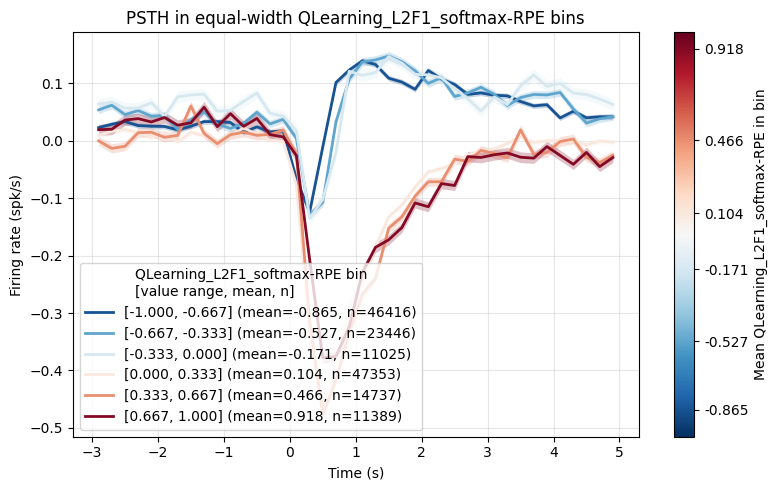

In [20]:
import importlib
import extract_psth_latent      # ← FIRST import the module
importlib.reload(extract_psth_latent)


from extract_psth_latent import (
    extract_response_psth_and_latent,
    load_response_psth_and_latent_zarr,
    plot_psth_quantiles_from_response_res,
)


zarr_path = "/root/capsule/scratch/psth_latent_allunits.zarr"
res = load_response_psth_and_latent_zarr(zarr_path)


plot_psth_quantiles_from_response_res(
    res,
    latent_name="QLearning_L2F1_softmax-RPE",
    n_quantiles=6,           # quartiles
    sort_ascending=True,
    cmap='RdBu_r'
)
